In [1]:
import os # For path compatibility on windows/linux/mac
import pprint
import matplotlib.pyplot as plt
import numpy as np

# Import the pyKasso package
import pykasso as pk

In [2]:
# Create a pyKasso application
app = pk.pykasso()

# Declare the grid parameters
grid_parameters = {
    'x0': 0, 'y0': 0, 'z0': 0,
    'nx': 300, 'ny': 300, 'nz': 1,
    'dx': 10, 'dy': 10, 'dz': 10
}

# Declare the project parameters
app.new_project(name='example_01', grid_parameters=grid_parameters)

In [3]:
# Declare the model parameters
model_parameters = {
    'inlets' : {
        'data' : [[0, 1500]],
        'number': 1
    },
    'outlets' : {
        'data' : [[2990, 1500]],
        'number' : 1
    },
    'fractures' : {
        'generate': {
            'family_01': {
                'density'      : 0.00005,
                'orientation'  : 135,
                'dip'          : 90,
                'length'       : 300,
            },
            'family_02': {
                'density'      : 0.00005,
                'orientation'  : 45,
                'dip'          : 90,
                'length'       : 500,
            }
        }
    },
    'sks' : {},
}

In [4]:
n_simulations = 10 # Number of simulations

for i in range(n_simulations):
    model_parameters['sks']['seed'] = 982198+i
    app.model.generate(model_parameters=model_parameters)

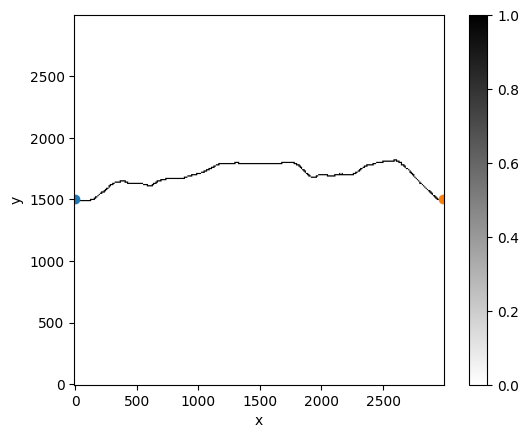

In [5]:
%matplotlib inline
f01 = app.visualizer.mpl_plot_2D(
    feature='karst',
    imshow_options={'cmap': 'binary'},
    scatter_inlets_options={},
    scatter_outlets_options={},
)

In [6]:
# pprint(vars(app.model))
app.model.maps['karst'][0].shape

(300, 300, 1)

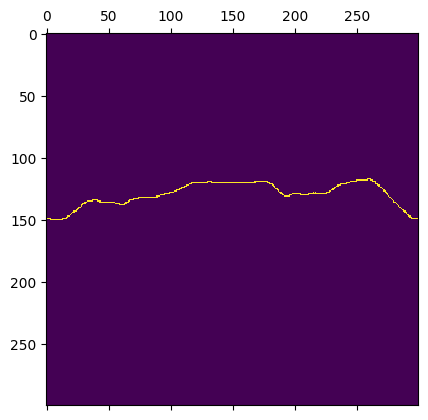

In [15]:
# we need to make sure that we represent the network correctly
# in the end, we need to flip the network (change the order of the rows)
# we then get the row-column representation for CFPy
plt.matshow(np.array(app.model.maps['karst'][0][:, :, 0].T[::-1, :]))